**IMPORT LIBRARY**

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

import joblib
import os

**Dataset Loading** 

In [2]:
!ls -R /kaggle/input

/kaggle/input:
datasets

/kaggle/input/datasets:
megharajeev24

/kaggle/input/datasets/megharajeev24:
enviroscan-pollution-source-labeled-dataset

/kaggle/input/datasets/megharajeev24/enviroscan-pollution-source-labeled-dataset:
enviro_labeled_dataset.csv


In [3]:
df = pd.read_csv("/kaggle/input/datasets/megharajeev24/enviroscan-pollution-source-labeled-dataset/enviro_labeled_dataset.csv")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (11151, 20)


,date,temperature,humidity,wind_speed,wind_direction,city,station,latitude,longitude,pm25,pm10,no2,so2,co,ozone,distance_to_major_road_km,distance_to_industrial_zone_km,distance_to_dump_site_km,distance_to_farmland_km,pollution_source
0,2025-01-01,19.52,55.29,2.01,68.7,AHEMEDABAD,AHEMEDABAD,23.03,72.54,44.200,96.410,39.45,3.780,0.01,32.14,0.633,0.826,1.381,4.49,Unknown / Mixed
1,2025-01-02,20.47,51.09,1.89,78.8,AHEMEDABAD,AHEMEDABAD,23.03,72.54,51.570,97.530,39.45,17.320,0.01,34.53,0.633,0.826,1.381,4.49,Unknown / Mixed
2,2025-01-03,20.88,48.41,1.68,105.1,AHEMEDABAD,AHEMEDABAD,23.03,72.54,42.905,88.455,39.45,24.970,0.01,26.57,0.633,0.826,1.381,4.49,Unknown / Mixed
3,2025-01-04,20.02,52.39,1.40,96.6,AHEMEDABAD,AHEMEDABAD,23.03,72.54,34.240,79.380,39.45,21.460,0.26,76.01,0.633,0.826,1.381,4.49,Unknown / Mixed
4,2025-01-05,19.15,53.01,1.65,319.6,AHEMEDABAD,AHEMEDABAD,23.03,72.54,57.170,99.660,35.51,12.225,0.28,34.77,0.633,0.826,1.381,4.49,Unknown / Mixed


In [4]:
df.isnull().sum()
df.columns
df["pollution_source"].value_counts()

pollution_source
Vehicular          4893
Unknown / Mixed    3979
Industrial         1452
Natural             823
Burning               4
Name: count, dtype: int64

**Feature Selection**

In [6]:
features = [
    "pm25","pm10","no2","so2","co","ozone",
    "temperature", "humidity","wind_speed","wind_direction",
    "distance_to_major_road_km",
    "distance_to_industrial_zone_km",
    "distance_to_dump_site_km",
    "distance_to_farmland_km"
]

X = df[features]
y = df["pollution_source"]

**Label Encoding**

In [7]:
encoder = LabelEncoder()
y = encoder.fit_transform(y)

print("Encoded Classes:", encoder.classes_)

Encoded Classes: ['Burning' 'Industrial' 'Natural' 'Unknown / Mixed' 'Vehicular']


In [8]:
print("Encoded Classes:", encoder.classes_)
print("First 10 labels:", y[:10])

Encoded Classes: ['Burning' 'Industrial' 'Natural' 'Unknown / Mixed' 'Vehicular']
First 10 labels: [3 3 3 3 3 3 2 3 2 2]


**Train Test Split**

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Size:", X_train.shape)
print("Testing Size:", X_test.shape)

Training Size: (8920, 14)
Testing Size: (2231, 14)


**Train Both Models**

**RANDOM FOREST**

In [10]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

rf_model.fit(X_train, y_train)

print("Random Forest trained")

Random Forest trained


**XG BOOST**

In [11]:
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric="mlogloss"
)

xgb_model.fit(X_train, y_train)

print("XGBoost trained")

XGBoost trained


**Hyperparameter Tuning**

**Tuning RandomForest**

In [12]:
rf_param_grid = {
"n_estimators":[100,200,300],
"max_depth":[5,10,15]
}

rf_grid = GridSearchCV(
RandomForestClassifier(random_state=42),
rf_param_grid,
cv=3,
scoring="accuracy"
)

rf_grid.fit(X_train,y_train)

print("RF Best Params:", rf_grid.best_params_)

RF Best Params: {'max_depth': 15, 'n_estimators': 200}


In [13]:
best_rf = rf_grid.best_estimator_

**Tuning XGboost**

In [14]:
param_grid = {
    "n_estimators": [100,200],
    "max_depth": [4,6,8],
    "learning_rate": [0.01,0.1]
}

grid_xgb = GridSearchCV(
    XGBClassifier(random_state=42, eval_metric="mlogloss"),
    param_grid,
    cv=3,
    scoring="accuracy"
)

grid_xgb.fit(X_train, y_train)

print("Best Parameters:", grid_xgb.best_params_)

Best Parameters: {'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 200}


In [15]:
best_xgb = grid_xgb.best_estimator_

**Compare Model Accuracy**

In [16]:
rf_pred = best_rf.predict(X_test)
xgb_pred = best_xgb.predict(X_test)

rf_acc = accuracy_score(y_test, rf_pred)
xgb_acc = accuracy_score(y_test, xgb_pred)

print("Random Forest Accuracy:", rf_acc)
print("XGBoost Accuracy:", xgb_acc)

Random Forest Accuracy: 0.9914836396234872
XGBoost Accuracy: 0.9919318691169879


**Select Best Model**

In [17]:
if xgb_acc > rf_acc:
    best_model = best_xgb
    model_name = "XGBoost"
else:
    best_model = best_rf
    model_name = "Random Forest"

print("Selected Model:", model_name)

Selected Model: XGBoost


**Final Evaluation**

In [18]:
pred = best_model.predict(X_test)

print(classification_report(y_test,pred))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.98      0.99      0.98       290
           2       1.00      0.99      1.00       165
           3       0.99      0.99      0.99       796
           4       1.00      1.00      1.00       979

    accuracy                           0.99      2231
   macro avg       0.79      0.79      0.79      2231
weighted avg       0.99      0.99      0.99      2231



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


**Confusion Matrix:**

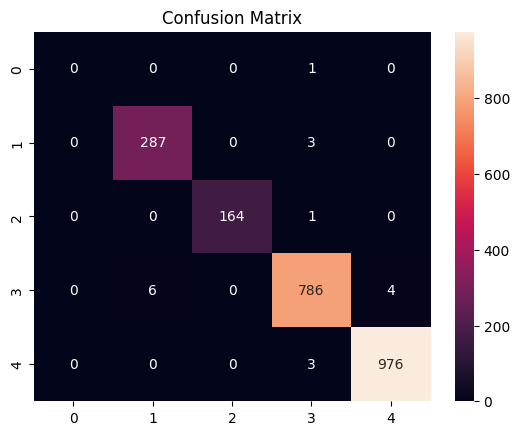

In [19]:
cm = confusion_matrix(y_test,pred)

sns.heatmap(cm,annot=True,fmt="d")
plt.title("Confusion Matrix")
plt.show()

**Feature Importance**

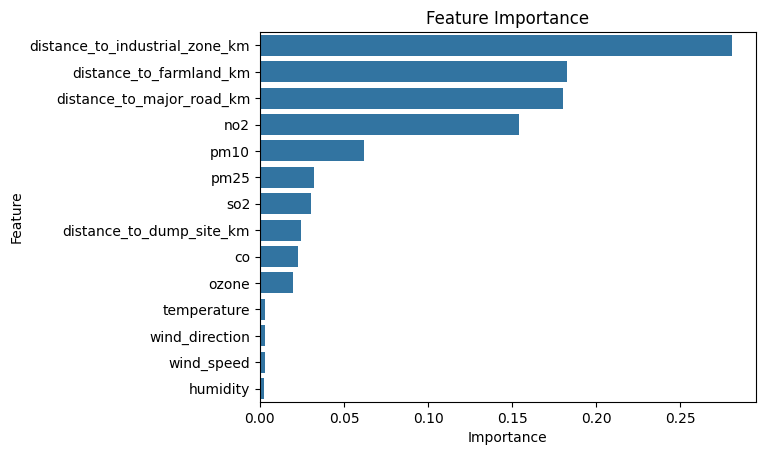

In [20]:
importance = best_model.feature_importances_

feat_imp = pd.DataFrame({
"Feature": X.columns,
"Importance": importance
}).sort_values(by="Importance",ascending=False)

sns.barplot(x="Importance",y="Feature",data=feat_imp)
plt.title("Feature Importance")
plt.show()

**Overfitting Check**

In [21]:
print("Train Accuracy:", best_model.score(X_train,y_train))
print("Test Accuracy:", best_model.score(X_test,y_test))

Train Accuracy: 1.0
Test Accuracy: 0.9919318691169879


**Export Final Model**

In [22]:
os.makedirs("models",exist_ok=True)

joblib.dump(best_model,"models/pollution_source_model.pkl")

print("Model saved successfully")

Model saved successfully


**TEST MODEL USING REAL DATA**

In [33]:
# Test prediction using one sample from test set

sample = X_test.iloc[0:1]

prediction = best_model.predict(sample)

print("Predicted Pollution Source:", encoder.inverse_transform(prediction))
print("Actual Pollution Source:", encoder.inverse_transform([y_test[0]]))

Predicted Pollution Source: ['Vehicular']
Actual Pollution Source: ['Vehicular']
